In [1]:
user = "\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

In [2]:
import numpy as np
import src.fluorophore_systems as fs
import src.custom_plot as cp

# On the laser intensity and the excitation rate
The laser intensity represents the number of photons per time released by the laser. This also dictates the excitation rate of the fluorophores, because the more photons the higher the probability of one hitting the electron of the fluorophore. The relationship is expected to be linear.\
Note that in biological samples, the number of excited molecules per time increases in a saturation curve with increasing laser intensity, because of the limited number of molecules in the system. 

In [3]:
rate_dict = dict(k_S1_S0=[1e9, ""])

excitation_rates = np.logspace(5, 15, 11)

In [4]:
means = []

for excitation_rate in excitation_rates:
    rate_dict["k_S0_S1"] = [excitation_rate, ""]
    system = fs.JablonskiModel(number=1, distances=1, rates=rate_dict)
    system.simulate(n_steps=100000, seed=97, base="py")
    system.process()
    system.emitters(unit="s", resample="0.01ms")
    pandas_series = system.pandas_series
    mean = np.mean(pandas_series.values)

    means.append(mean)

If the excitation rate is $10^6s^{-1}$ and the emission rate is $10^9s^{-1}$, the emission rate is very close to the excitation rate (see value below).

In [8]:
means[1] / (0.01*10**-3)

998203.2341784787

(<Figure size 1000x500 with 1 Axes>,
 [<AxesSubplot:xlabel='excitation rate', ylabel='mean events per 0.01ms'>])

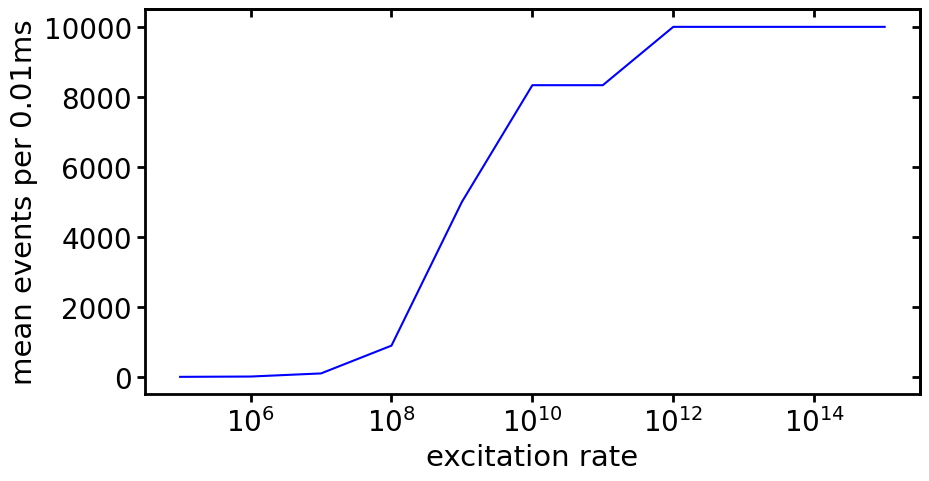

In [10]:
cp.universal_figure(type_="line", data=[excitation_rates, means], xscale="log", 
                    ylabel="mean events per 0.01ms", xlabel="excitation rate")

0.01 ms is 1e-5 s. The limiting rate here is the rate of emission with 1e8 events per second or 1 event per 1e-8 s. This indicates that if one can consider the excited state to be instantaneously (very high rate) occupied, 1e-5/1e-8 = 1000 events (on average) to be happening. 

The graph above shows that with increasing excitation rate there will be a saturation due to the limited emission rate (fluorescence), therefore if the laser intensity is sufficiently high, the saturation point is passed and one can treat the excitation rate as instantaneous. \
A more important aspect here is to consider the excitation of substances with very low extinction coefficients, e.g., the Cy-SR(-) absorption at 650 nm. The effect of laser intensity on this rather low rate is expected to have a bigger influence. 

## With triplet state

In [9]:
rate_dict = dict(k_S1_S0=[1e9, ""],
                 k_S1_T1=[1e6, ""],
                 k_T1_S0=[5e5, ""])

excitation_rates = np.logspace(5, 15, 11)

In [10]:
means = []

for excitation_rate in excitation_rates:
    rate_dict["k_S0_S1"] = [excitation_rate, ""]
    system = fs.JablonskiModel(number=1, distances=1, rates=rate_dict)
    system.simulate(n_steps=100000, seed=97, base="py")
    system.process()
    system.emitters(unit="s", resample="0.01ms")
    pandas_series = system.pandas_series
    mean = np.mean(pandas_series.values)

    means.append(mean)

In [11]:
means[1] / (0.01*10**-3)

994600.5180314804

The triplet state has no big impact on the overall emission rate.